In [46]:
import pandas as pd 
import numpy as np

In [47]:
# D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\1.customer-churn-prediction-using-ann

In [48]:
# df = pd.read_csv("D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\1.customer-churn-prediction-using-ann/Churn_Modelling.csv")

In [49]:
import pandas as pd

DATA_PATH = r"D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\1.customer-churn-prediction-using-ann\Churn_Modelling.csv"

df = pd.read_csv(DATA_PATH)

display(df.head())

print("Shape:", df.shape)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Shape: (10000, 14)


In [50]:
print("Info:",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
Info: None


In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [53]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [54]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [55]:
df.drop(columns = ['RowNumber','CustomerId','Surname'], inplace = True)

In [56]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [57]:
df = pd.get_dummies(df, columns=['Geography','Gender'] , dtype=int, drop_first = True)

In [58]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [59]:
X = df.drop(columns = ['Exited'])
y = df['Exited']

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(X,y, test_size=0.2, random_state= 1)

In [61]:
X_train.shape

(8000, 11)

In [62]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [63]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [64]:
import tensorflow

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# model  = Sequential()

# model.add(Dense(11, activation = 'relu', input_dim =11))
# model.add(Dense(11, activation = 'relu'))
# model.add(Dense(1, activation= 'sigmoid'))

d:\Problem_Solving_Practice\Deep_Learning\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model  = Sequential()

model.add(Dense(11, activation = 'relu', input_dim =11))
model.add(Dense(11, activation = 'relu'))
model.add(Dense(1, activation= 'sigmoid'))

In [66]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam' , metrics=['accuracy'])


In [68]:
history = model.fit(X_train_scaled , y_train , epochs = 100 , validation_split=0.2 )

Epoch 1/100


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7709 - loss: 0.5433 - val_accuracy: 0.7994 - val_loss: 0.4823
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8059 - loss: 0.4518 - val_accuracy: 0.8087 - val_loss: 0.4396
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8117 - loss: 0.4175 - val_accuracy: 0.8200 - val_loss: 0.4109
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.3935 - val_accuracy: 0.8275 - val_loss: 0.3881
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8403 - loss: 0.3759 - val_accuracy: 0.8356 - val_loss: 0.3725
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8495 - loss: 0.3649 - val_accuracy: 0.8388 - val_loss: 0.3647
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8553 - loss: 0.3584 - val_accuracy: 0.8438 - val_loss: 0.3601
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8548 - loss: 0.3543 - val_accuracy: 0.8438

In [69]:
model.layers[0].get_weights()

[array([[-1.1745834e-01,  8.9939088e-02, -8.2084320e-02,  4.1759911e-01,
         -3.4695748e-02, -8.3039254e-02, -4.5464505e-02, -2.6122043e-01,
          1.4483611e-01, -2.4869089e-01,  1.7947571e-01],
        [ 7.5458282e-01,  1.0923246e+00,  6.1635458e-01, -8.2083058e-01,
         -2.7452347e-01, -2.7073604e-01, -3.4307456e-01, -8.0265206e-01,
          1.0759482e-01,  7.4256521e-01, -4.9414578e-01],
        [ 6.2364742e-02,  2.8151382e-02,  5.2530490e-02, -4.1636616e-01,
          7.9156168e-02,  2.8785584e-02, -2.9645965e-01,  7.4010670e-02,
          4.7697598e-01,  1.0470718e-01, -8.0642998e-03],
        [-7.5440817e-02,  2.3133475e-02,  4.6619818e-02, -5.5673029e-02,
         -6.2123227e-01, -7.0721930e-01, -8.1679040e-01,  2.3784606e-01,
          7.0656583e-02, -3.5054913e-01,  1.2071991e-01],
        [ 1.0175928e+00, -7.2054267e-01,  1.4068850e+00, -1.8976539e-01,
         -2.0532267e-01,  4.0424559e-03, -1.5001211e-01, -3.6003420e-01,
          1.7567816e-01, -1.0026157e-0

In [70]:
model.layers[1].get_weights()

[array([[ 0.01249572, -0.19956481,  0.68358094,  0.3434471 , -0.526024  ,
         -0.5999854 , -1.5955437 ,  0.7012185 , -0.47748938,  0.10356957,
         -0.30620334],
        [-0.41472968,  0.4144556 , -0.46967357,  0.56587964, -0.444183  ,
         -0.3125981 ,  0.29666427, -0.33834872,  0.43079147, -0.41999093,
         -0.2977945 ],
        [ 0.64778864,  0.09256388,  0.82945985,  0.09898525, -0.23419751,
          0.32904714, -0.77539593, -0.06857998, -1.3948767 ,  0.2927229 ,
          0.51725715],
        [-0.04653954,  0.71737814, -0.1597061 , -0.47742066, -0.23276141,
          0.40736768, -0.4901105 ,  0.5653374 , -0.14248335, -0.15614565,
          0.04035186],
        [ 0.30788118,  0.17935356, -0.14187922,  0.08159617,  0.26785696,
          0.01707728,  0.40630057,  0.15002184, -0.13543163, -0.7531295 ,
          0.4430566 ],
        [ 0.21566702, -0.3115311 , -1.0592169 , -0.44752592,  0.21801181,
          0.41698432,  0.45520267,  0.32451758,  0.17236711, -0.2579278

In [71]:
model.layers[2].get_weights()

[array([[-0.39900416],
        [-0.7774832 ],
        [ 1.0416209 ],
        [ 0.82983345],
        [-0.87352586],
        [-0.74300516],
        [ 1.2754598 ],
        [ 0.4499636 ],
        [ 1.9788342 ],
        [ 0.7775343 ],
        [-0.6620819 ]], dtype=float32),
 array([-0.05731478], dtype=float32)]

In [72]:
y_log= model.predict(X_test_scaled)   # output is probablity so we will convert it into 0 and 1 by deciding a threshold

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [73]:
y_pred =  np.where(y_log >0.5, 1, 0)

In [74]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [1]], shape=(2000, 1))

In [75]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8625

## To increase accuracy 
1. we can increase number of nodes in hidden layer .
2. choose a good activation function like reLU .
3. Increase number of epoch

In [76]:
import matplotlib.pyplot as plt

In [77]:
history.history

{'accuracy': [0.7709375023841858,
  0.8059375286102295,
  0.811718761920929,
  0.824999988079071,
  0.8403124809265137,
  0.8495312333106995,
  0.8553125262260437,
  0.8548437356948853,
  0.8540624976158142,
  0.8570312261581421,
  0.8610937595367432,
  0.8595312237739563,
  0.8612499833106995,
  0.8621875047683716,
  0.8628125190734863,
  0.8620312213897705,
  0.8618749976158142,
  0.862500011920929,
  0.8628125190734863,
  0.8637499809265137,
  0.8623437285423279,
  0.8646875023841858,
  0.8650000095367432,
  0.8643749952316284,
  0.8645312786102295,
  0.8656250238418579,
  0.8648437261581421,
  0.8637499809265137,
  0.8642187714576721,
  0.8646875023841858,
  0.8657812476158142,
  0.8650000095367432,
  0.8650000095367432,
  0.8651562333106995,
  0.866406261920929,
  0.8660937547683716,
  0.8662499785423279,
  0.867968738079071,
  0.8668749928474426,
  0.866406261920929,
  0.8659374713897705,
  0.8643749952316284,
  0.8656250238418579,
  0.8656250238418579,
  0.8665624856948853,
  0.

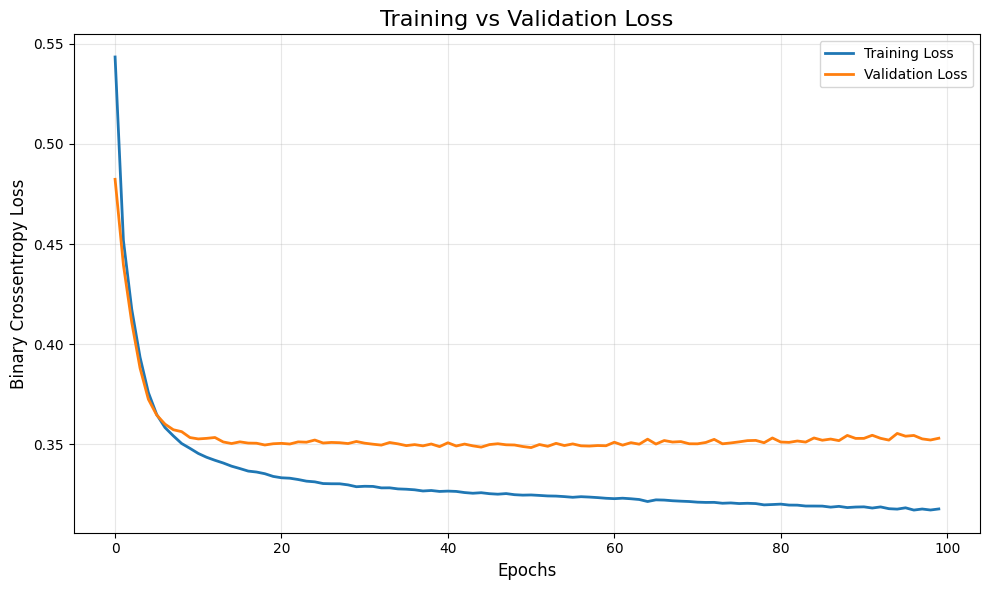

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Training vs Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Binary Crossentropy Loss', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

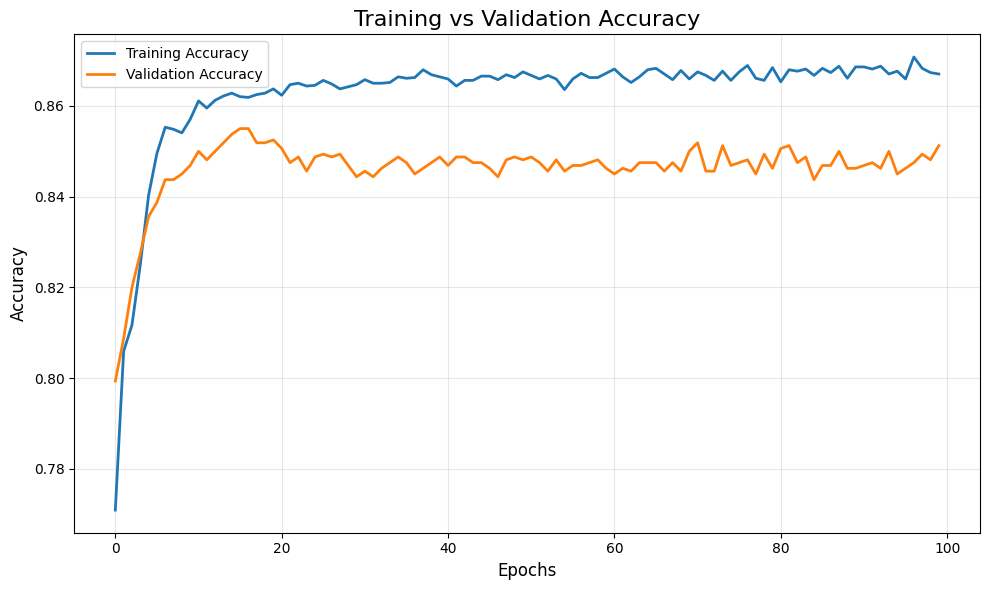

In [79]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.title('Training vs Validation Accuracy', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()